In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE

In [2]:
cust_df = pd.read_csv("Churn_Modelling.csv")

In [3]:
cust_df.shape

(10000, 14)

In [4]:
cust_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
cust_df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [6]:
cust_df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
cust_df.isnull()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
cust_df.isnull().values.any()

np.False_

In [9]:
cust_df=cust_df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [10]:
cust_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
cust_df.tail()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [12]:
cust_df.shape

(10000, 11)

In [13]:
# Select only numeric columns for the correlation calculation
numeric_df = cust_df.select_dtypes(include=['int64', 'float64'])

In [14]:
# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

In [15]:
# Display the correlation matrix
print(correlation_matrix)

                 CreditScore       Age    Tenure   Balance  NumOfProducts  \
CreditScore         1.000000 -0.003965  0.000842  0.006268       0.012238   
Age                -0.003965  1.000000 -0.009997  0.028308      -0.030680   
Tenure              0.000842 -0.009997  1.000000 -0.012254       0.013444   
Balance             0.006268  0.028308 -0.012254  1.000000      -0.304180   
NumOfProducts       0.012238 -0.030680  0.013444 -0.304180       1.000000   
HasCrCard          -0.005458 -0.011721  0.022583 -0.014858       0.003183   
IsActiveMember      0.025651  0.085472 -0.028362 -0.010084       0.009612   
EstimatedSalary    -0.001384 -0.007201  0.007784  0.012797       0.014204   
Exited             -0.027094  0.285323 -0.014001  0.118533      -0.047820   

                 HasCrCard  IsActiveMember  EstimatedSalary    Exited  
CreditScore      -0.005458        0.025651        -0.001384 -0.027094  
Age              -0.011721        0.085472        -0.007201  0.285323  
Tenure       

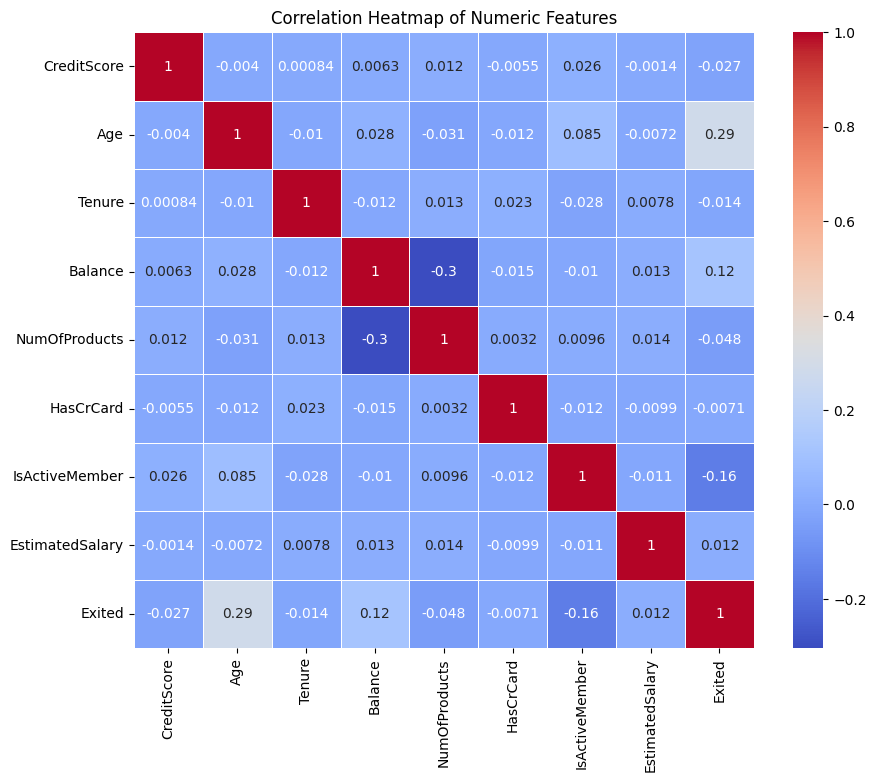

In [16]:
# Plot the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

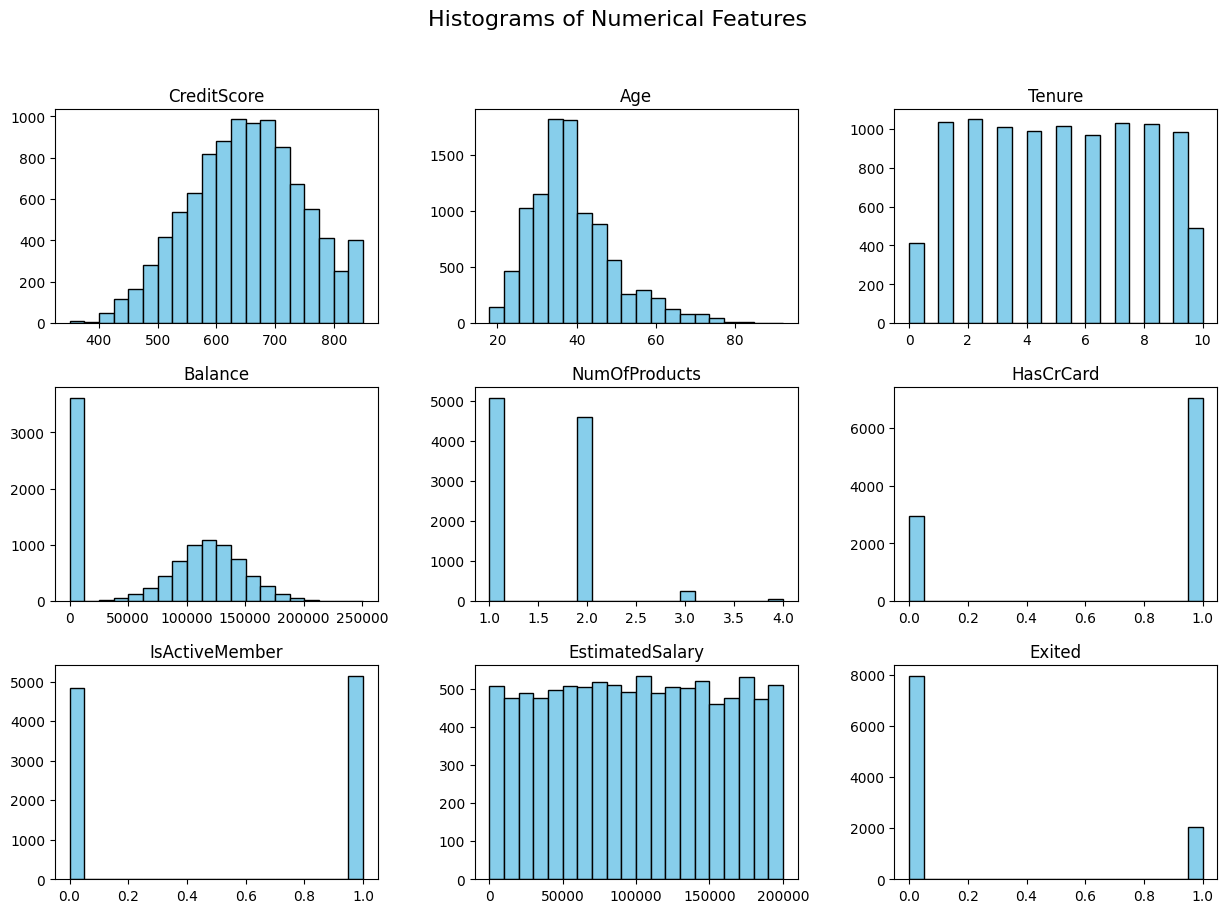

In [17]:
# Generate histograms for numerical columns
numerical_columns = cust_df.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms
cust_df[numerical_columns].hist(bins=20, figsize=(15, 10), grid=False, color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.show()

In [18]:
# Set plot style for better aesthetics
sns.set(style="whitegrid")

In [19]:
# List of categorical columns in your dataset
categorical_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Exited']

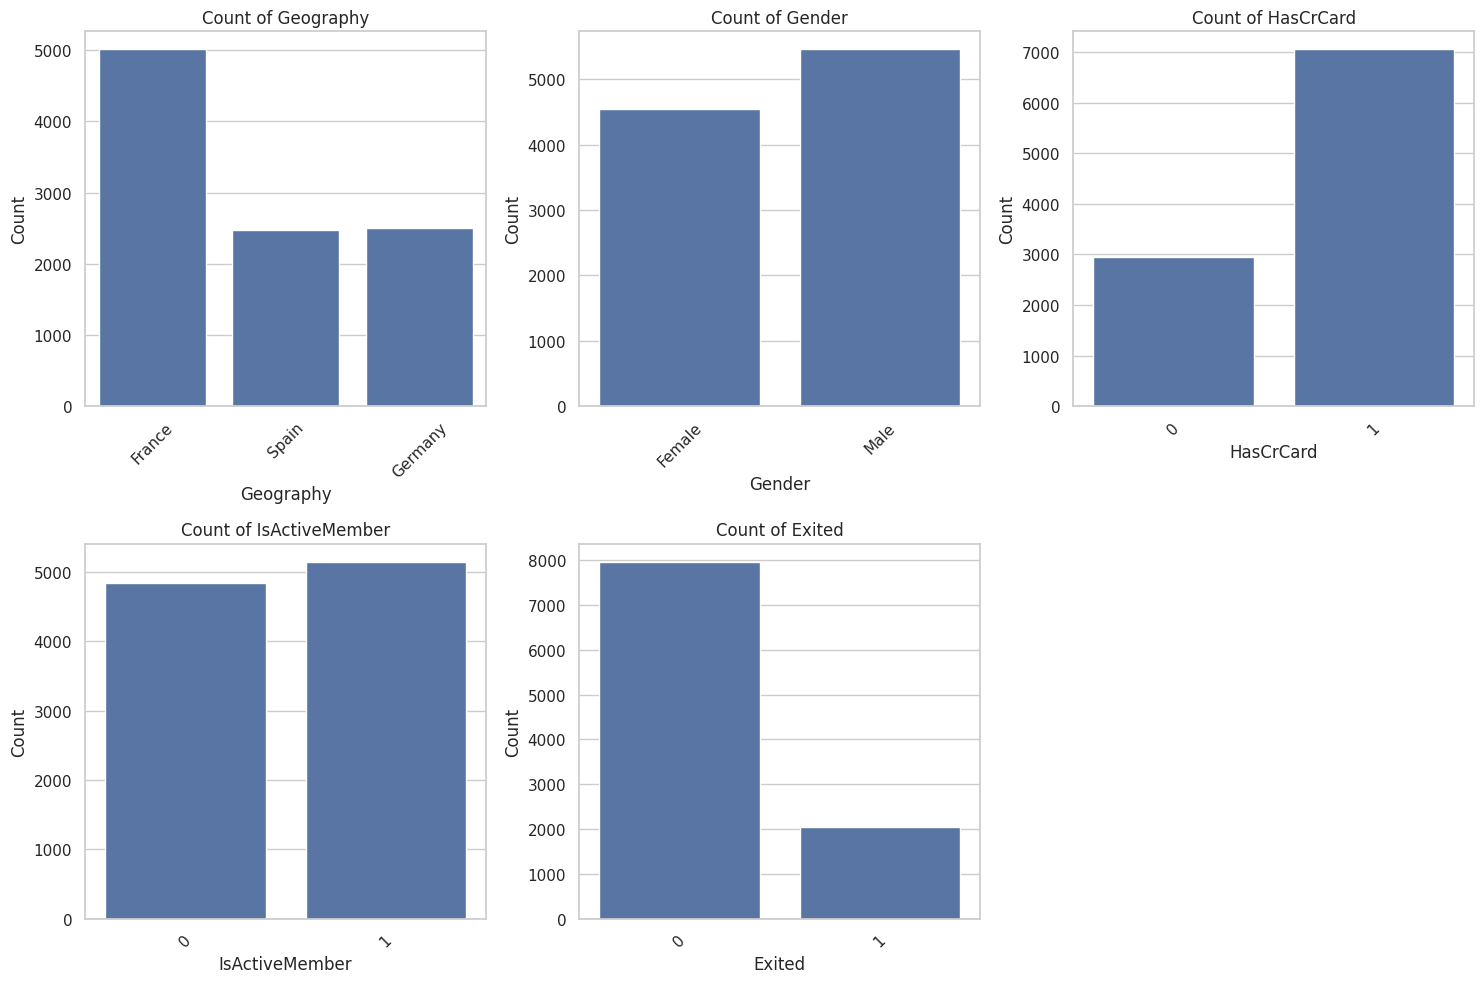

In [20]:
# Plot bar charts for each categorical variable
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)  # Create a grid of subplots
    sns.countplot(data=cust_df, x=col)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# Count the occurrences of Gender status (0: Female, 1: Male)
gender_counts = cust_df['Gender'].value_counts()

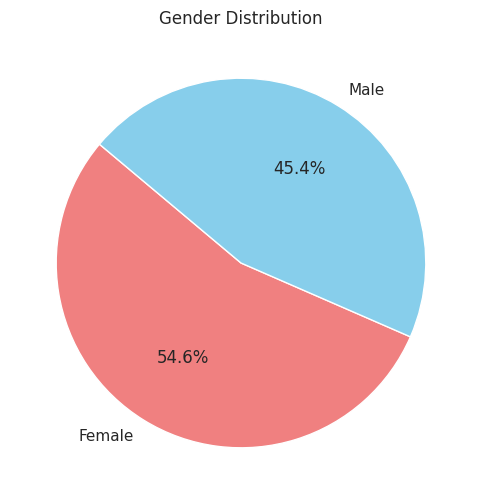

In [22]:
# Plotting the pie chart for Travel Insurance distribution
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=['Female', 'Male'], autopct='%1.1f%%', startangle=140, colors=['lightcoral', 'skyblue'])
plt.title('Gender Distribution')
plt.show()

In [23]:
# Count the occurrences of Gender status (0: France, 1: Spain, 2: Germany)
country_counts = cust_df['Geography'].value_counts()

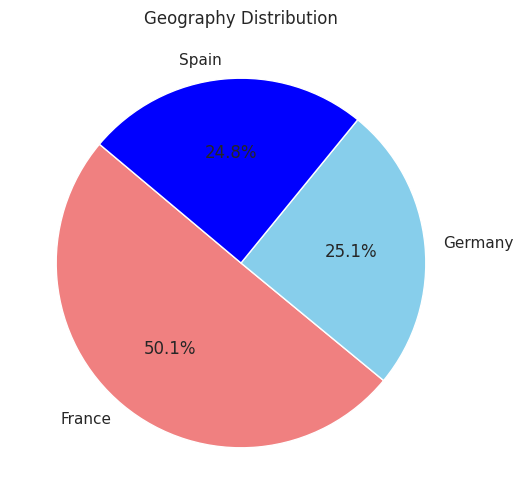

In [24]:
plt.figure(figsize=(6, 6))
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightcoral', 'skyblue', 'blue'])
plt.title('Geography Distribution')
plt.show()

In [25]:
# Count the occurrences of Gender status (0: Not Exited, 1: Exited)
Exited_counts = cust_df['Exited'].value_counts()

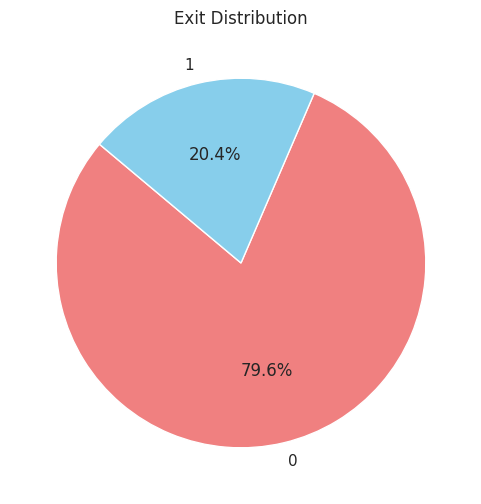

In [26]:
plt.figure(figsize=(6, 6))
plt.pie(Exited_counts, labels=Exited_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightcoral', 'skyblue'])
plt.title('Exit Distribution')
plt.show()

In [27]:
# Encoding categorical variables
le = LabelEncoder()
cust_df['Gender'] = LabelEncoder().fit_transform(cust_df['Gender'])

In [28]:
#Encoding the Geographical feature through the One hot encoding
encoder = OneHotEncoder(sparse_output=False)
encoded_geography = encoder.fit_transform(cust_df[['Geography']])

In [29]:
# Convert encoded features into DataFrame
encoded_df = pd.DataFrame(encoded_geography, columns=encoder.get_feature_names_out(['Geography']))

In [30]:
# Merge with the original DataFrame (excluding original categorical column)
cust_df_encoded = pd.concat([cust_df.drop('Geography', axis=1), encoded_df], axis=1)
print("\nAfter One-Hot Encoding:")
print(cust_df_encoded)


After One-Hot Encoding:
      CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0             619       0   42       2       0.00              1          1   
1             608       0   41       1   83807.86              1          0   
2             502       0   42       8  159660.80              3          1   
3             699       0   39       1       0.00              2          0   
4             850       0   43       2  125510.82              1          1   
...           ...     ...  ...     ...        ...            ...        ...   
9995          771       1   39       5       0.00              2          1   
9996          516       1   35      10   57369.61              1          1   
9997          709       0   36       7       0.00              1          0   
9998          772       1   42       3   75075.31              2          1   
9999          792       0   28       4  130142.79              1          1   

      IsActiveMember  Esti

In [32]:
# Encoding categorical variables
le = LabelEncoder()
cust_df_encoded['Gender'] = LabelEncoder().fit_transform(cust_df['Gender'])

In [33]:
X = cust_df_encoded.drop('Exited', axis=1)
y = cust_df_encoded['Exited']
print(cust_df_encoded)

      CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0             619       0   42       2       0.00              1          1   
1             608       0   41       1   83807.86              1          0   
2             502       0   42       8  159660.80              3          1   
3             699       0   39       1       0.00              2          0   
4             850       0   43       2  125510.82              1          1   
...           ...     ...  ...     ...        ...            ...        ...   
9995          771       1   39       5       0.00              2          1   
9996          516       1   35      10   57369.61              1          1   
9997          709       0   36       7       0.00              1          0   
9998          772       1   42       3   75075.31              2          1   
9999          792       0   28       4  130142.79              1          1   

      IsActiveMember  EstimatedSalary  Exited  Geog

In [34]:
#Normalizing the Dataset
scaler = MinMaxScaler()

In [35]:
X[['CreditScore','Age', 'Balance', 'EstimatedSalary']] = scaler.fit_transform(X[['CreditScore','Age', 'Balance', 'EstimatedSalary']])

In [36]:
#Train and Test dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
#Builing the Model
model = Sequential()
model.add(Dense(32, input_dim=X_train.shape[1], activation='relu'))
#This is the Batch normalization layer
model.add(BatchNormalization())
model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(8, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
#Compile the Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [39]:
#Fit the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=32)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6871 - loss: 0.6175 - val_accuracy: 0.8200 - val_loss: 0.4482
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8010 - loss: 0.4465 - val_accuracy: 0.8415 - val_loss: 0.4023
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8221 - loss: 0.4170 - val_accuracy: 0.8320 - val_loss: 0.3943
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8269 - loss: 0.3996 - val_accuracy: 0.8445 - val_loss: 0.3809
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8344 - loss: 0.3901 - val_accuracy: 0.8480 - val_loss: 0.3760
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8335 - loss: 0.3904 - val_accuracy: 0.8510 - val_loss: 0.3702
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8385 - loss: 0.3823 - val_accuracy: 0.8480 - val_loss: 0.3709
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8371 - loss: 0.3806 - val_accuracy: 0.

In [40]:
#Test Accuracy
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8570 - loss: 0.3494
Test Accuracy: 85.70%


In [41]:
# Predict on test data
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


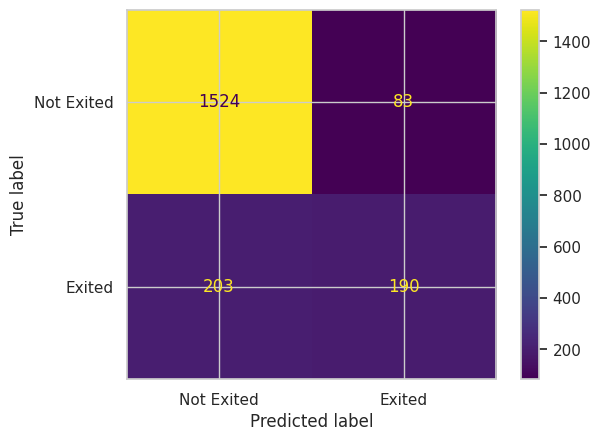

In [42]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Exited", "Exited"]).plot();

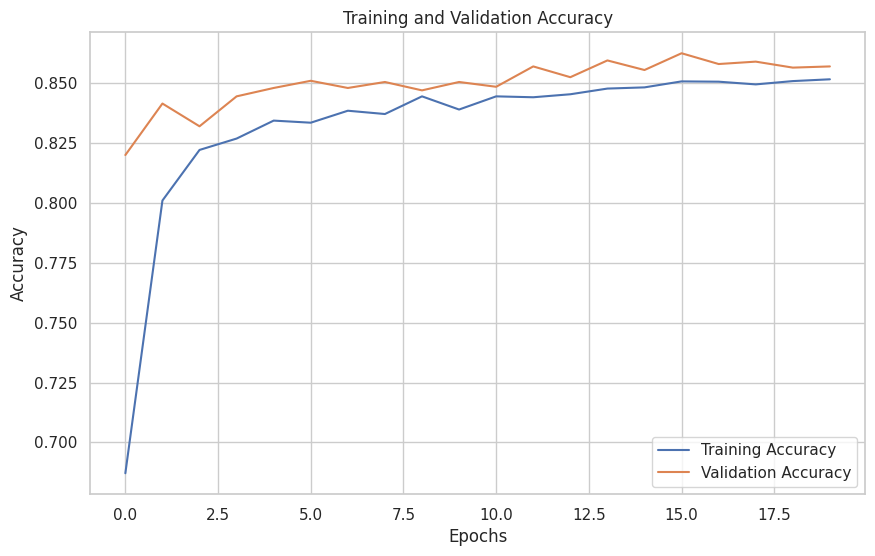

In [43]:
# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\
Model Accuracy:", accuracy)

Model Accuracy: 0.857


In [45]:
# Print classification report
from sklearn.metrics import classification_report
print("\
Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1607
           1       0.70      0.48      0.57       393

    accuracy                           0.86      2000
   macro avg       0.79      0.72      0.74      2000
weighted avg       0.85      0.86      0.85      2000



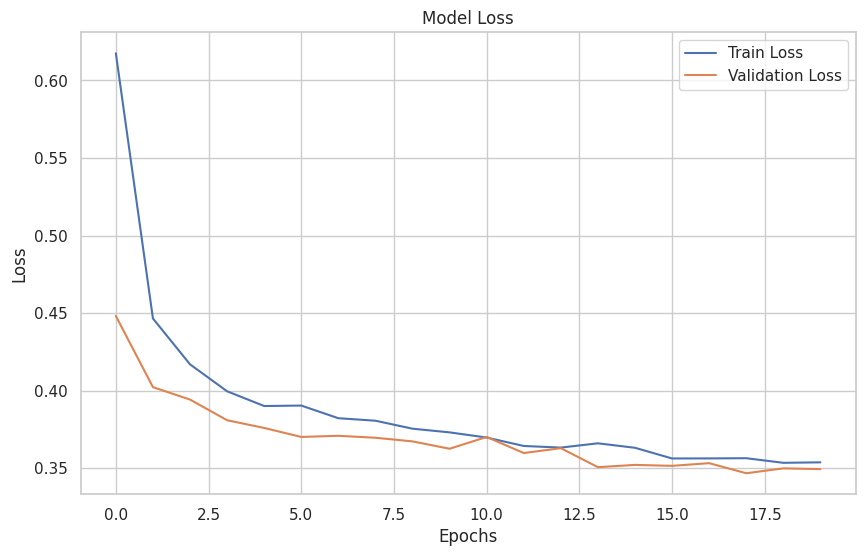

In [46]:
# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
Exited_counts = cust_df_encoded['Exited'].value_counts()

In [48]:
print("Exited_counts:")

Exited_counts:


In [49]:
print(Exited_counts)

Exited
0    7963
1    2037
Name: count, dtype: int64


In [50]:
kappa = cohen_kappa_score(y_test, y_pred)

print("Kappa: %.2f" %kappa)

Kappa: 0.49


In [51]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, cohen_kappa_score

In [52]:
accuracy_ANN = accuracy_score(y_test, y_pred)
F1_ANN = f1_score(y_test, y_pred)
recall_ANN = recall_score(y_test, y_pred)
precision_ANN = precision_score(y_test, y_pred)
kappa_value_ANN = cohen_kappa_score(y_test, y_pred)

# Displaying metrics
print("\nModel Performance Metrics:")
print(f"Accuracy Score: {accuracy_ANN * 100:.2f}%")
print(f"F1 Score: {F1_ANN:.4f}")
print(f"Recall: {recall_ANN:.4f}")
print(f"Precision: {precision_ANN:.4f}")
print(f"Cohen's Kappa: {kappa_value_ANN:.4f}")


Model Performance Metrics:
Accuracy Score: 85.70%
F1 Score: 0.5706
Recall: 0.4835
Precision: 0.6960
Cohen's Kappa: 0.4881


In [53]:
Exited_counts = cust_df_encoded['Exited'].value_counts()

In [54]:
print("Exited_counts:")

Exited_counts:


In [55]:
print(Exited_counts)

Exited
0    7963
1    2037
Name: count, dtype: int64


In [56]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split before applying SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [57]:
print(y_train)

2151    1
8392    1
5006    0
4117    0
7182    0
       ..
4555    1
4644    0
8942    0
2935    0
6206    0
Name: Exited, Length: 8000, dtype: int64


In [58]:
Exited_counts = y_train.value_counts()

In [59]:
print("Exited_counts:")

Exited_counts:


In [60]:
print(Exited_counts)

Exited
0    6370
1    1630
Name: count, dtype: int64


In [61]:
#Builing the Model
model = Sequential()
model.add(Dense(32, input_dim=X_train.shape[1], activation='relu'))
#This is the Batch normalization layer
model.add(BatchNormalization())
model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(8, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
#Compile the Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [63]:
#Fit the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=32)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7110 - loss: 0.5829 - val_accuracy: 0.8105 - val_loss: 0.4808
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8171 - loss: 0.4325 - val_accuracy: 0.8255 - val_loss: 0.4168
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8282 - loss: 0.4009 - val_accuracy: 0.8415 - val_loss: 0.3838
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8356 - loss: 0.3881 - val_accuracy: 0.8410 - val_loss: 0.3793
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8422 - loss: 0.3773 - val_accuracy: 0.8485 - val_loss: 0.3779
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8351 - loss: 0.3782 - val_accuracy: 0.8490 - val_loss: 0.3715
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8420 - loss: 0.3694 - val_accuracy: 0.8505 - val_loss: 0.3698
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8432 - loss: 0.3667 - val_accuracy: 0.

In [64]:
#Test Accuracy
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8670 - loss: 0.3449
Test Accuracy: 86.70%


In [65]:
# Predict on test data
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


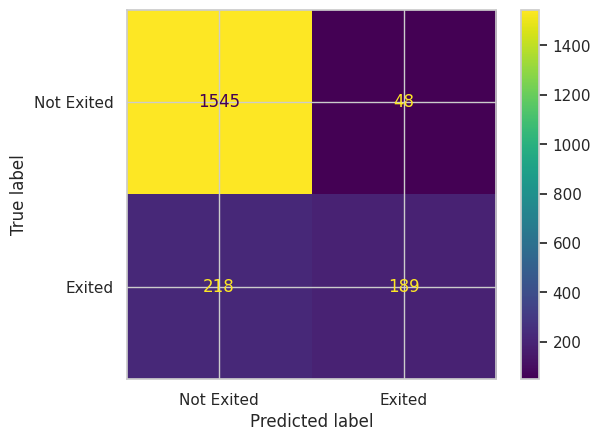

In [66]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Exited", "Exited"]).plot();

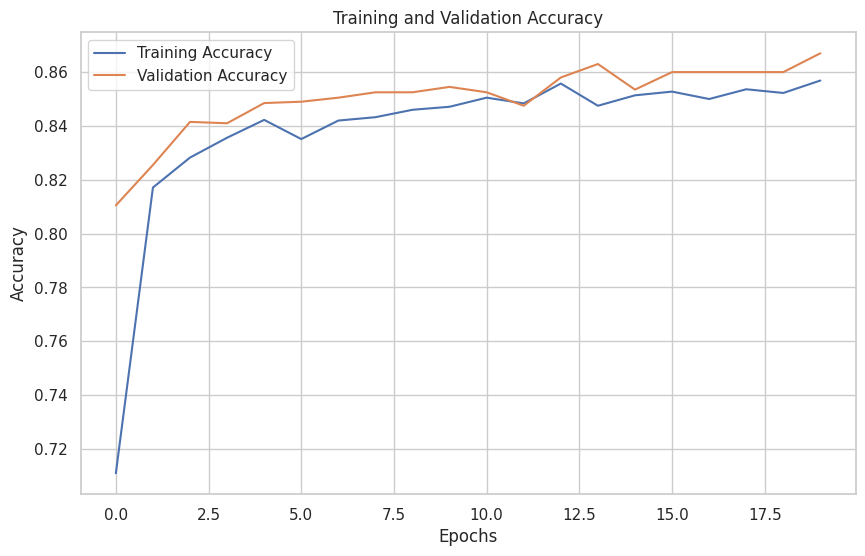

In [67]:
# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [68]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\
Model Accuracy:", accuracy)

Model Accuracy: 0.867


In [69]:
# Print classification report
from sklearn.metrics import classification_report
print("\
Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.46      0.59       407

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



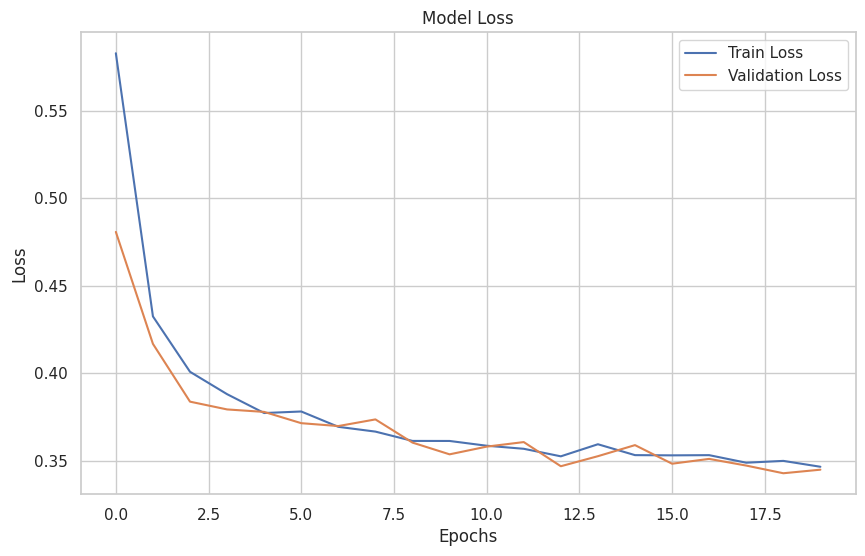

In [70]:
# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [71]:
kappa = cohen_kappa_score(y_test, y_pred)

print("Kappa: %.2f" %kappa)

Kappa: 0.51


In [72]:
accuracy_ANN = accuracy_score(y_test, y_pred)
F1_ANN = f1_score(y_test, y_pred)
recall_ANN = recall_score(y_test, y_pred)
precision_ANN = precision_score(y_test, y_pred)
kappa_value_ANN = cohen_kappa_score(y_test, y_pred)

# Displaying metrics
print("\nModel Performance Metrics:")
print(f"Accuracy Score: {accuracy_ANN * 100:.2f}%")
print(f"F1 Score: {F1_ANN:.4f}")
print(f"Recall: {recall_ANN:.4f}")
print(f"Precision: {precision_ANN:.4f}")
print(f"Cohen's Kappa: {kappa_value_ANN:.4f}")


Model Performance Metrics:
Accuracy Score: 86.70%
F1 Score: 0.5870
Recall: 0.4644
Precision: 0.7975
Cohen's Kappa: 0.5142


In [73]:
#Builing the Model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
#This is the Batch normalization layer
model.add(BatchNormalization())
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [74]:
#Compile the Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [75]:
Exited_counts = y_train.value_counts()

In [76]:
print("Exited counts:")

Exited counts:


In [77]:
print(Exited_counts)

Exited
0    6370
1    1630
Name: count, dtype: int64


In [78]:
#Fit the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=64)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.6967 - loss: 0.6073 - val_accuracy: 0.7550 - val_loss: 0.5585
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8121 - loss: 0.4569 - val_accuracy: 0.7995 - val_loss: 0.4747
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8329 - loss: 0.4009 - val_accuracy: 0.8135 - val_loss: 0.4140
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8405 - loss: 0.3822 - val_accuracy: 0.8435 - val_loss: 0.3824
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8395 - loss: 0.3729 - val_accuracy: 0.8430 - val_loss: 0.3811
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8435 - loss: 0.3686 - val_accuracy: 0.8430 - val_loss: 0.3779
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8464 - loss: 0.3641 - val_accuracy: 0.8430 - val_loss: 0.3750
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8461 - loss: 0.3613 - val_accuracy: 0

In [79]:
print(Exited_counts)

Exited
0    6370
1    1630
Name: count, dtype: int64


In [80]:
#Test Accuracy
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8325 - loss: 0.3993
Test Accuracy: 83.25%


In [81]:
# Predict on test data
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


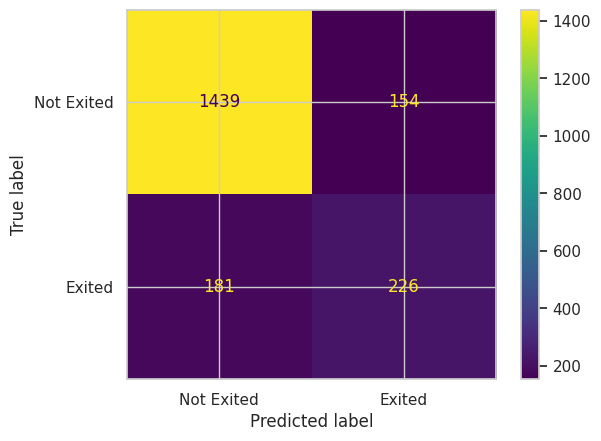

In [82]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Exited", "Exited"]).plot();

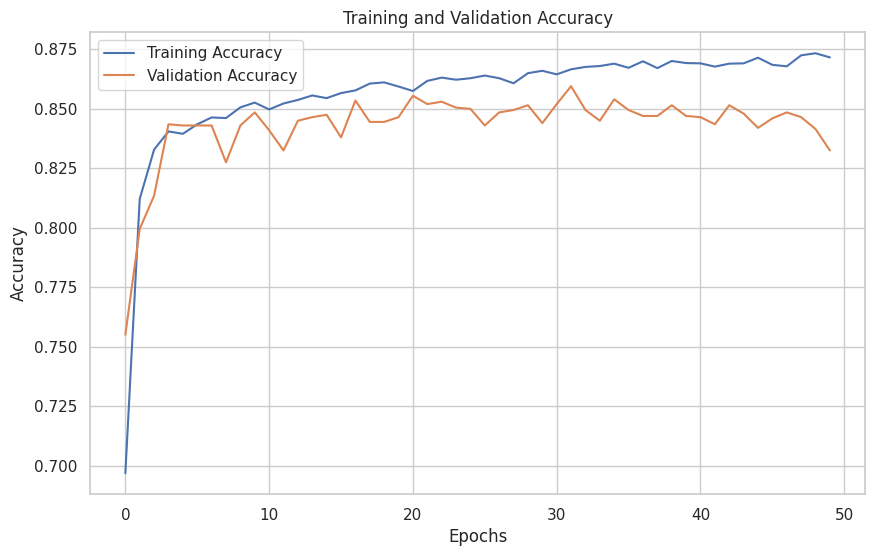

In [83]:
# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [84]:
!pip install scikeras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.optimizers import Adam, RMSprop
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define custom tags for the KerasClassifier to be compatible with scikit-learn >= 1.5.0
_custom_tags_data = {
    "estimator_type": "classifier",
    "poor_score": False,
    "no_validation": False,
    "requires_y": True,
    "requires_fit": True,
    "preserves_dtype": [np.float32], # Keras models often output float32
    "non_deterministic": False,
    "binary_only": True, # Assuming a binary classification problem
    "allow_nan": False,
    "stateless": False,
    "multioutput": False,
    "trains_unsupervised": False,
    "X_types": ["2darray"],
    "y_types": ["binary_ndarray"],
    "allow_variable_length": False,
}

# Define a custom KerasClassifier subclass to correctly implement __sklearn_tags__
# and __sklearn_is_fitted__ properties without calling super() to avoid the AttributeError.
class CustomKerasClassifier(KerasClassifier):
    @property
    def __sklearn_tags__(self):
        # Return our predefined tags directly, bypassing any super() call from BaseEstimator.
        return _custom_tags_data

    @property
    def __sklearn_is_fitted__(self):
        # A KerasClassifier is considered fitted if its underlying Keras model exists
        return hasattr(self, 'model_') and self.model_ is not None

In [ ]:
def create_model(learning_rate=0.001, neurons1=64, neurons2=32, neurons3=16):
    model = Sequential()
    model.add(Dense(neurons1, input_dim=X_train.shape[1], activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(neurons2, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(neurons3, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(1, activation='sigmoid'))

    # Optimizer
    optimizer = Adam(learning_rate=learning_rate)

    model.compile(loss='binary_crossentropy',
                  optimizer=optimizer,
                  metrics=['accuracy'])
    return model

In [86]:
model = KerasClassifier(build_fn=create_model, verbose=0)
# Workaround for scikit-learn versions >= 1.5.0 compatibility with scikeras
model._sklearn_version_for_tags = "1.4"

param_dist = {
    'learning_rate': [0.0001, 0.0005, 0.001, 0.005],
    'neurons1': [32, 64, 128],
    'neurons2': [16, 32, 64],
    'neurons3': [8, 16, 32],
    'batch_size': [16, 32, 64, 128],
    'epochs': [20, 50, 100]
}

In [108]:
import inspect

# Define a custom _get_tags method that's compatible with scikit-learn >= 1.5.0
# This dictionary contains the standard tags expected by scikit-learn for a classifier.
_custom_tags = {
    "estimator_type": "classifier",
    "poor_score": False,
    "no_validation": False,
    "requires_y": True,
    "requires_fit": True,
    "preserves_dtype": [np.float32], # Keras models often output float32
    "non_deterministic": False,
    "binary_only": True, # Assuming a binary classification problem
    "allow_nan": False,
    "stateless": False,
    "multioutput": False,
    "trains_unsupervised": False,
    "X_types": ["2darray"],
    "y_types": ["binary_ndarray"],
    "allow_variable_length": False,
}

# This function will be assigned to KerasClassifier._get_tags
def _get_tags_patch(self):
    return _custom_tags

# This function explicitly overrides KerasClassifier.__sklearn_tags__
# to return our custom tags and prevent the problematic super() call.
def _sklearn_tags_patch(self):
    return _custom_tags

# Define __sklearn_is_fitted__ property for scikit-learn >= 1.5.0
def _sklearn_is_fitted_patch(self):
    # A KerasClassifier is considered fitted if its underlying Keras model exists
    return hasattr(self, 'model_') and self.model_ is not None

# Apply the patches directly to the KerasClassifier class
# Use a unique attribute to ensure patching only happens once in interactive environments
if not hasattr(KerasClassifier, '_patched_for_sklearn_1_5_fix_v2'):
    KerasClassifier._get_tags = _get_tags_patch
    KerasClassifier.__sklearn_tags__ = _sklearn_tags_patch # Explicitly override __sklearn_tags__
    KerasClassifier.__sklearn_is_fitted__ = property(_sklearn_is_fitted_patch)
    KerasClassifier._patched_for_sklearn_1_5_fix_v2 = True # Mark as patched

# Re-instantiate the model after patching the KerasClassifier class
model = KerasClassifier(build_fn=create_model, verbose=0)
# The _sklearn_version_for_tags workaround is for scikeras internal logic,
# but the direct class method patching addresses the sklearn.base compatibility.
# It's kept here for potential continued internal compatibility with scikeras.
model._sklearn_version_for_tags = "1.4"

param_dist = {
    'learning_rate': [0.0001, 0.0005, 0.001, 0.005],
    'neurons1': [32, 64, 128],
    'neurons2': [16, 32, 64],
    'neurons3': [8, 16, 32],
    'batch_size': [16, 32, 64, 128],
    'epochs': [20, 50, 100]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,            # number of models to try
    cv=3,                 # 3-fold cross validation
    verbose=2,
    random_state=42,
    scoring='accuracy'    # Explicitly set the scoring parameter
)

random_search.fit(X_train_res, y_train_res) # Use resampled data for fitting

AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [92]:
pip install scikeras

In [100]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np # Ensure numpy is imported for the patch
import inspect # Required for the patch

# Define a custom _get_tags method that's compatible with scikit-learn >= 1.5.0
# This dictionary contains the standard tags expected by scikit-learn for a classifier.
_custom_tags = {
    "estimator_type": "classifier",
    "poor_score": False,
    "no_validation": False,
    "requires_y": True,
    "requires_fit": True,
    "preserves_dtype": [np.float32], # Keras models often output float32
    "non_deterministic": False,
    "binary_only": True, # Assuming a binary classification problem
    "allow_nan": False,
    "stateless": False,
    "multioutput": False,
    "trains_unsupervised": False,
    "X_types": ["2darray"],
    "y_types": ["binary_ndarray"],
    "allow_variable_length": False,
}

# This function will be assigned to KerasClassifier._get_tags
def _get_tags_patch(self):
    return _custom_tags

# This function explicitly overrides KerasClassifier.__sklearn_tags__
# to return our custom tags and prevent the problematic super() call.
def _sklearn_tags_patch(self):
    return _custom_tags

# Define __sklearn_is_fitted__ property for scikit-learn >= 1.5.0
def _sklearn_is_fitted_patch(self):
    # A KerasClassifier is considered fitted if its underlying Keras model exists
    return hasattr(self, 'model_') and self.model_ is not None

# Apply the patches directly to the KerasClassifier class
# Use a unique attribute to ensure patching only happens once in interactive environments
if not hasattr(KerasClassifier, '_patched_for_sklearn_1_5_fix_v2'):
    KerasClassifier._get_tags = _get_tags_patch
    KerasClassifier.__sklearn_tags__ = property(_sklearn_tags_patch) # Explicitly override __sklearn_tags__ as a property
    KerasClassifier.__sklearn_is_fitted__ = property(_sklearn_is_fitted_patch)
    KerasClassifier._patched_for_sklearn_1_5_fix_v2 = True # Mark as patched

# Re-instantiate the model after patching the KerasClassifier class
# Note: This block is redundant if the CustomKerasClassifier approach is used
# model = KerasClassifier(build_fn=create_model, verbose=0)
# The _sklearn_version_for_tags workaround is for scikeras internal logic,
# but the direct class method patching addresses the sklearn.base compatibility.
# It's kept here for potential continued internal compatibility with scikeras.
# model._sklearn_version_for_tags = "1.4"

# param_dist = {
#     'learning_rate': [0.0001, 0.0005, 0.001, 0.005],
#     'neurons1': [32, 64, 128],
#     'neurons2': [16, 32, 64],
#     'neurons3': [8, 16, 32],
#     'batch_size': [16, 32, 64, 128],
#     'epochs': [20, 50, 100]
# }

# random_search = RandomizedSearchCV(
#     estimator=model,
#     param_distributions=param_dist,
#     n_iter=20,            # number of models to try
#     cv=3,                 # 3-fold cross validation
#     verbose=2,
#     random_state=42,
#     scoring='accuracy'    # Explicitly set the scoring parameter
# )

# random_search.fit(X_train_res, y_train_res) # Use resampled data for fitting

In [94]:
def create_model(learning_rate=0.001, neurons1=64, neurons2=32, neurons3=16):
    model = Sequential()
    model.add(Dense(neurons1, input_dim=X_train.shape[1], activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(neurons2, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(neurons3, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(loss="binary_crossentropy",
                  optimizer=optimizer,
                  metrics=["accuracy"])
    return model

In [101]:
model = CustomKerasClassifier(
    model=create_model,
    verbose=0
)
# Re-apply the specific workaround for scikit-learn versions >= 1.5.0 compatibility
# This is necessary as `_sklearn_version_for_tags` is an instance attribute.
model._sklearn_version_for_tags = "1.4"

In [96]:
param_dist = {
    "model__learning_rate": [0.0001, 0.0005, 0.001, 0.005],
    "model__neurons1": [32, 64, 128],
    "model__neurons2": [16, 32, 64],
    "model__neurons3": [8, 16, 32],
    "batch_size": [16, 32, 64, 128],
    "epochs": [20, 50, 100]
}

In [102]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    scoring='accuracy' # Explicitly set scoring for clarity
)

random_search.fit(X_train_res, y_train_res)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [103]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.7 MB/s eta 0:00:00


In [104]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [105]:
def build_model(hp):
    model = Sequential()

    # Layer 1
    model.add(Dense(
        units=hp.Int("neurons1", 32, 128, step=32),
        activation="relu",
        input_dim=X_train.shape[1]
    ))
    model.add(BatchNormalization())

    # Layer 2
    model.add(Dense(
        units=hp.Int("neurons2", 16, 64, step=16),
        activation="relu"
    ))
    model.add(BatchNormalization())

    # Layer 3
    model.add(Dense(
        units=hp.Int("neurons3", 8, 32, step=8),
        activation="relu"
    ))
    model.add(BatchNormalization())

    model.add(Dense(1, activation="sigmoid"))

    # Learning Rate
    lr = hp.Choice("learning_rate", [0.0001, 0.0005, 0.001, 0.005])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [106]:
tuner = kt.Hyperband(
    build_model,
    objective="val_accuracy",
    max_epochs=50,
    factor=3,
    directory="ann_tuning",
    project_name="ann_batchnorm"
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [107]:
tuner.search(
    X_train_res,
    y_train_res,
    epochs=50,
    validation_split=0.2
)

Trial 90 Complete [00h 01m 13s]
val_accuracy: 0.848901093006134

Best val_accuracy So Far: 0.8649921417236328
Total elapsed time: 00h 28m 31s


In [109]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Hyperparameters:")
print(best_hp.values)

Best Hyperparameters:
{'neurons1': 32, 'neurons2': 64, 'neurons3': 32, 'learning_rate': 0.005, 'tuner/epochs': 50, 'tuner/initial_epoch': 17, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0069'}


In [110]:
final_model = tuner.hypermodel.build(best_hp)

history = final_model.fit(
    X_train_res,
    y_train_res,
    epochs=best_hp.get("tuner/epochs"),
    batch_size=32,        # or tune this too
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7286 - loss: 0.5414 - val_accuracy: 0.6966 - val_loss: 0.5720
Epoch 2/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7780 - loss: 0.4698 - val_accuracy: 0.7700 - val_loss: 0.5184
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7854 - loss: 0.4520 - val_accuracy: 0.6935 - val_loss: 0.6123
Epoch 4/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7938 - loss: 0.4477 - val_accuracy: 0.6515 - val_loss: 0.6559
Epoch 5/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7894 - loss: 0.4463 - val_accuracy: 0.5126 - val_loss: 0.8889
Epoch 6/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7933 - loss: 0.4407 - val_accuracy: 0.7520 - val_loss: 0.6144
Epoch 7/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7961 - loss: 0.4368 - val_accuracy: 0.7182 - val_loss: 0.5633
Epoch 8/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7977 - loss: 0.4361 - val_accuracy: 0.

In [111]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("\n🔹 Best Hyperparameters Found:")
for param, val in best_hp.values.items():
    print(f"{param}: {val}")


🔹 Best Hyperparameters Found:
neurons1: 32
neurons2: 64
neurons3: 32
learning_rate: 0.005
tuner/epochs: 50
tuner/initial_epoch: 17
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0069


In [112]:
history = final_model.fit(
    X_train_res,
    y_train_res,
    epochs=best_hp.get("tuner/epochs"),
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8314 - loss: 0.3711 - val_accuracy: 0.8148 - val_loss: 0.4089
Epoch 2/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8273 - loss: 0.3731 - val_accuracy: 0.8414 - val_loss: 0.3737
Epoch 3/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8358 - loss: 0.3676 - val_accuracy: 0.7912 - val_loss: 0.4447
Epoch 4/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8388 - loss: 0.3594 - val_accuracy: 0.7818 - val_loss: 0.4651
Epoch 5/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8341 - loss: 0.3659 - val_accuracy: 0.7233 - val_loss: 0.5655
Epoch 6/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8326 - loss: 0.3682 - val_accuracy: 0.8034 - val_loss: 0.4397
Epoch 7/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8341 - loss: 0.3674 - val_accuracy: 0.7767 - val_loss: 0.4916
Epoch 8/50
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8350 - loss: 0.3577 - val_accuracy: 0

In [113]:
print("\n🔹 Final Model Training Performance:")
print("Final Training Accuracy :", history.history['accuracy'][-1])
print("Final Training Loss     :", history.history['loss'][-1])
print("Validation Accuracy     :", history.history['val_accuracy'][-1])
print("Validation Loss         :", history.history['val_loss'][-1])



🔹 Final Model Training Performance:
Final Training Accuracy : 0.8483123779296875
Final Training Loss     : 0.3429449498653412
Validation Accuracy     : 0.8563579320907593
Validation Loss         : 0.3271028399467468


In [114]:
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)

print("\n🔹 Test Set Performance:")
print("Test Accuracy:", test_acc)
print("Test Loss    :", test_loss)



🔹 Test Set Performance:
Test Accuracy: 0.8195000290870667
Test Loss    : 0.4357703924179077


In [115]:
from sklearn.metrics import classification_report

y_pred = (final_model.predict(X_test) > 0.5).astype(int)

print("\n🔹 Detailed Classification Report:")
print(classification_report(y_test, y_pred))


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

🔹 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1593
           1       0.54      0.69      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.75      2000
weighted avg       0.84      0.82      0.83      2000



In [116]:
from sklearn.metrics import classification_report

y_pred = (final_model.predict(X_test) > 0.5).astype(int)

print("\n🔹 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

🔹 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1593
           1       0.54      0.69      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.75      2000
weighted avg       0.84      0.82      0.83      2000



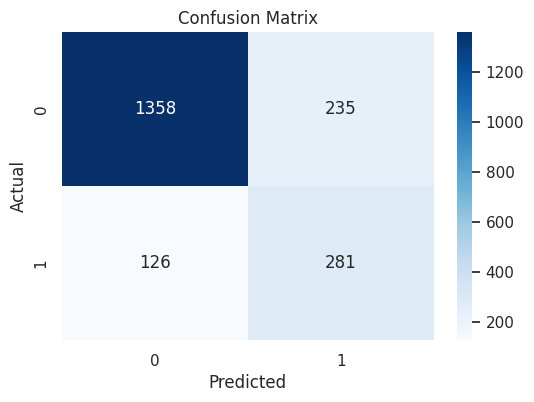

In [117]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

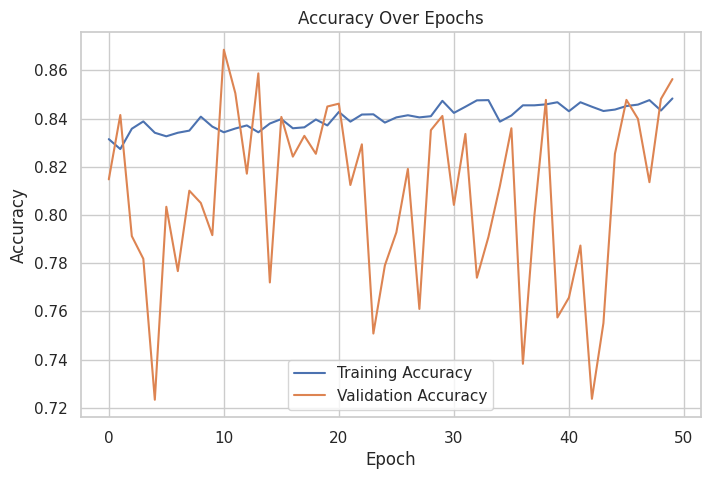

In [118]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

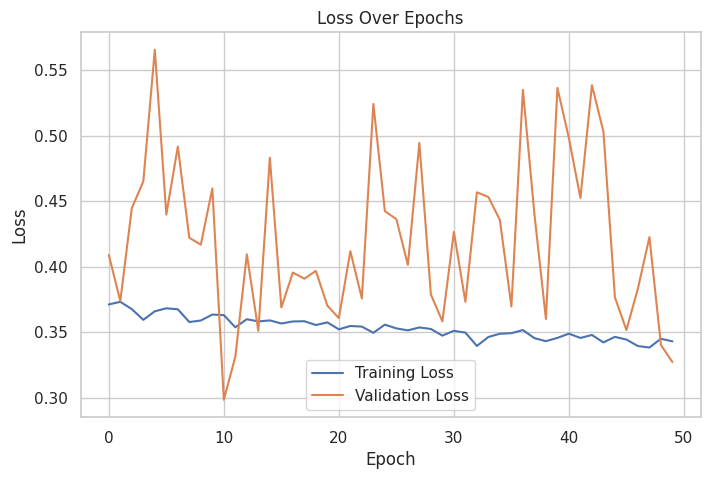

In [119]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


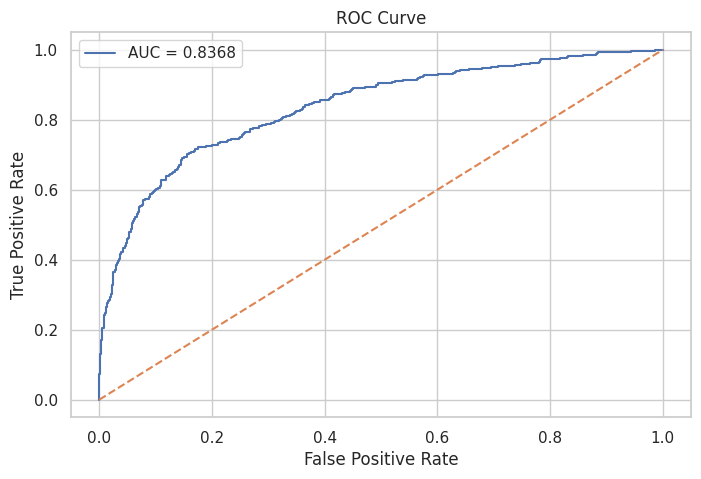


🔹 AUC Score: 0.8368059893483621


In [120]:
from sklearn.metrics import roc_curve, auc

y_prob = final_model.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = auc(fpr, tpr)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print("\n🔹 AUC Score:", auc_score)

In [121]:
final_model.save("best_ann_model.h5")
print("\nModel saved as best_ann_model.h5")



Model saved as best_ann_model.h5
